# Sales Data Cleaning & Business Analysis

## Project Overview

This project analyzes a multi-year retail sales dataset containing 10,194 transaction records and 21 columns.

The objective is to:

- Audit the dataset for data-quality issues
- Prepare a clean analysis-ready dataset
- Analyze sales and profitability
- Identify high-performing and loss-making categories
- Investigate discount-related profitability
- Identify products and regions contributing to losses
- Produce business-oriented recommendations

## Dataset

- Rows: 10,194
- Columns: 21
- Unique Orders: 5,111
- Unique Customers: 804
- Unique Products: 1,862

## Tools Used

- Python
- Pandas
- Matplotlib
- Jupyter Notebook
- Excel

## Analysis Workflow

1. Data loading
2. Data structure and type inspection
3. Missing-value analysis
4. Duplicate analysis
5. Data validation
6. Data cleaning
7. KPI analysis
8. Category and sub-category analysis
9. Monthly trend analysis
10. Discount and profitability analysis
11. Product-level investigation
12. Regional investigation
13. Business insights and recommendations

In [1]:
import pandas as pd

In [2]:
file_path = "../data/sample_-_superstore.xls"

df = pd.read_excel(file_path, sheet_name="Orders")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,US-2023-103800,2023-01-03,2023-01-07,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512
1,2,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870
2,3,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717
3,4,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748
4,5,US-2023-141817,2023-01-05,2023-01-12,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,...,19143,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840


In [3]:
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}")

Rows: 10,194
Columns: 21


In [4]:
df.columns.tolist()

['Row ID',
 'Order ID',
 'Order Date',
 'Ship Date',
 'Ship Mode',
 'Customer ID',
 'Customer Name',
 'Segment',
 'Country/Region',
 'City',
 'State/Province',
 'Postal Code',
 'Region',
 'Product ID',
 'Category',
 'Sub-Category',
 'Product Name',
 'Sales',
 'Quantity',
 'Discount',
 'Profit']

In [5]:
df.dtypes

Row ID                     int64
Order ID                     str
Order Date        datetime64[us]
Ship Date         datetime64[us]
Ship Mode                    str
Customer ID                  str
Customer Name                str
Segment                      str
Country/Region               str
City                         str
State/Province               str
Postal Code               object
Region                       str
Product ID                   str
Category                     str
Sub-Category                 str
Product Name                 str
Sales                    float64
Quantity                   int64
Discount                 float64
Profit                   float64
dtype: object

# 1. Data Quality Assessment

Before performing business analysis, the dataset was inspected for structural and quality issues.

The following checks were performed:

- Dataset dimensions
- Column names
- Data types
- Missing values
- Duplicate rows
- Duplicate Order IDs
- Duplicate Row IDs
- Invalid dates
- Invalid discounts
- Invalid quantities
- Zero sales
- Negative sales
- Customer ID/name consistency
- Product ID/name consistency
- Product category consistency
- Product sub-category consistency

In [6]:
missing_values = df.isnull().sum()

missing_values

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country/Region    0
City              0
State/Province    0
Postal Code       0
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Quantity          0
Discount          0
Profit            0
dtype: int64

In [7]:
duplicate_rows = df.duplicated().sum()

print(f"Duplicate rows: {duplicate_rows}")

Duplicate rows: 0


In [8]:
duplicate_order_ids = df["Order ID"].duplicated().sum()

print(f"Duplicate Order IDs: {duplicate_order_ids}")

Duplicate Order IDs: 5083


In [9]:
order_id_counts = df["Order ID"].value_counts()

print(f"Total rows: {len(df):,}")
print(f"Unique orders: {df['Order ID'].nunique():,}")
print(f"Orders with multiple products: {(order_id_counts > 1).sum():,}")
print(f"Maximum rows for one order: {order_id_counts.max()}")

Total rows: 10,194
Unique orders: 5,111
Orders with multiple products: 2,518
Maximum rows for one order: 14


In [10]:
order_id_counts.head(10)

Order ID
US-2026-100111    14
US-2026-157987    12
US-2025-108504    11
US-2025-165330    11
US-2024-131338    10
US-2024-126977    10
US-2025-105732    10
US-2023-106439     9
US-2024-163433     9
US-2024-132626     9
Name: count, dtype: int64

In [11]:
categorical_columns = [
    "Ship Mode",
    "Segment",
    "Country/Region",
    "Region",
    "Category",
    "Sub-Category"
]

for column in categorical_columns:
    print(f"\n{'=' * 50}")
    print(f"{column}")
    print(f"{'=' * 50}")
    print(df[column].value_counts())


Ship Mode
Ship Mode
Standard Class    6120
Second Class      1979
First Class       1548
Same Day           547
Name: count, dtype: int64

Segment
Segment
Consumer       5281
Corporate      3090
Home Office    1823
Name: count, dtype: int64

Country/Region
Country/Region
United States    9994
Canada            200
Name: count, dtype: int64

Region
Region
West       3253
East       2986
Central    2335
South      1620
Name: count, dtype: int64

Category
Category
Office Supplies    6128
Furniture          2201
Technology         1865
Name: count, dtype: int64

Sub-Category
Sub-Category
Binders        1548
Paper          1384
Furnishings    1009
Phones          903
Storage         856
Art             821
Accessories     775
Chairs          634
Appliances      474
Labels          368
Tables          326
Envelopes       256
Bookcases       232
Fasteners       229
Supplies        192
Machines        117
Copiers          70
Name: count, dtype: int64


In [12]:
text_columns = [
    "Order ID",
    "Ship Mode",
    "Customer ID",
    "Customer Name",
    "Segment",
    "Country/Region",
    "City",
    "State/Province",
    "Region",
    "Product ID",
    "Category",
    "Sub-Category",
    "Product Name"
]

for column in text_columns:
    leading_spaces = df[column].astype(str).str.startswith(" ").sum()
    trailing_spaces = df[column].astype(str).str.endswith(" ").sum()
    
    if leading_spaces > 0 or trailing_spaces > 0:
        print(
            f"{column}: "
            f"{leading_spaces} leading spaces, "
            f"{trailing_spaces} trailing spaces"
        )

In [13]:
numeric_columns = ["Sales", "Quantity", "Discount", "Profit"]

for column in numeric_columns:
    print(f"\n{column}")
    print(f"Minimum: {df[column].min()}")
    print(f"Maximum: {df[column].max()}")
    print(f"Negative values: {(df[column] < 0).sum()}")


Sales
Minimum: 0.44399999999999995
Maximum: 22638.48
Negative values: 0

Quantity
Minimum: 1
Maximum: 14
Negative values: 0

Discount
Minimum: 0.0
Maximum: 0.8
Negative values: 0

Profit
Minimum: -6599.978000000001
Maximum: 8399.975999999999
Negative values: 1901


In [14]:
invalid_ship_dates = df[df["Ship Date"] < df["Order Date"]]

print(f"Orders shipped before order date: {len(invalid_ship_dates):,}")

Orders shipped before order date: 0


In [15]:
invalid_discounts = df[
    (df["Discount"] < 0) | (df["Discount"] > 1)
]

print(f"Invalid discount values: {len(invalid_discounts):,}")

Invalid discount values: 0


In [16]:
invalid_quantity = df[df["Quantity"] <= 0]

print(f"Invalid quantity values: {len(invalid_quantity):,}")

Invalid quantity values: 0


In [17]:
duplicate_row_ids = df["Row ID"].duplicated().sum()

print(f"Duplicate Row IDs: {duplicate_row_ids:,}")

Duplicate Row IDs: 0


In [18]:
zero_sales = (df["Sales"] == 0).sum()

print(f"Rows with zero sales: {zero_sales:,}")

Rows with zero sales: 0


In [19]:
customer_name_counts = df.groupby("Customer ID")["Customer Name"].nunique()

inconsistent_customers = customer_name_counts[
    customer_name_counts > 1
]

print(
    f"Customer IDs linked to multiple names: "
    f"{len(inconsistent_customers):,}"
)

Customer IDs linked to multiple names: 0


In [20]:
product_name_counts = df.groupby("Product ID")["Product Name"].nunique()

inconsistent_products = product_name_counts[
    product_name_counts > 1
]

print(
    f"Product IDs linked to multiple product names: "
    f"{len(inconsistent_products):,}"
)

Product IDs linked to multiple product names: 32


In [21]:
product_category_counts = df.groupby("Product ID")["Category"].nunique()

inconsistent_product_categories = product_category_counts[
    product_category_counts > 1
]

print(
    f"Product IDs linked to multiple categories: "
    f"{len(inconsistent_product_categories):,}"
)

Product IDs linked to multiple categories: 0


In [22]:
product_subcategory_counts = df.groupby("Product ID")["Sub-Category"].nunique()

inconsistent_product_subcategories = product_subcategory_counts[
    product_subcategory_counts > 1
]

print(
    f"Product IDs linked to multiple sub-categories: "
    f"{len(inconsistent_product_subcategories):,}"
)

Product IDs linked to multiple sub-categories: 0


In [23]:
inconsistent_product_ids = inconsistent_products.index

product_name_conflicts = (
    df[df["Product ID"].isin(inconsistent_product_ids)]
    [["Product ID", "Product Name", "Category", "Sub-Category"]]
    .drop_duplicates()
    .sort_values(["Product ID", "Product Name"])
)

product_name_conflicts

,Product ID,Product Name,Category,Sub-Category
1158,FUR-BO-10002213,DMI Eclipse Executive Suite Bookcases,Furniture,Bookcases
2882,FUR-BO-10002213,"Sauder Forest Hills Library, Woodland Oak Finish",Furniture,Bookcases
5592,FUR-CH-10001146,"Global Task Chair, Black",Furniture,Chairs
100,FUR-CH-10001146,"Global Value Mid-Back Manager's Chair, Gray",Furniture,Chairs
236,FUR-FU-10001473,DAX Wood Document Frame,Furniture,Furnishings
...,...,...,...,...
6766,TEC-PH-10002200,Samsung Galaxy Note 2,Technology,Phones
858,TEC-PH-10002310,Panasonic KX T7731-B Digital phone,Technology,Phones
2410,TEC-PH-10002310,Plantronics Calisto P620-M USB Wireless Speake...,Technology,Phones
401,TEC-PH-10004531,AT&T CL2909,Technology,Phones


In [24]:
product_name_conflicts.groupby("Product ID").size().value_counts().sort_index()

2    32
Name: count, dtype: int64

In [25]:
product_name_conflicts["Product Name Length"] = (
    product_name_conflicts["Product Name"].astype(str).str.len()
)

product_name_conflicts[
    ["Product ID", "Product Name", "Product Name Length"]
]

,Product ID,Product Name,Product Name Length
1158,FUR-BO-10002213,DMI Eclipse Executive Suite Bookcases,37
2882,FUR-BO-10002213,"Sauder Forest Hills Library, Woodland Oak Finish",48
5592,FUR-CH-10001146,"Global Task Chair, Black",24
100,FUR-CH-10001146,"Global Value Mid-Back Manager's Chair, Gray",43
236,FUR-FU-10001473,DAX Wood Document Frame,23
...,...,...,...
6766,TEC-PH-10002200,Samsung Galaxy Note 2,21
858,TEC-PH-10002310,Panasonic KX T7731-B Digital phone,34
2410,TEC-PH-10002310,Plantronics Calisto P620-M USB Wireless Speake...,59
401,TEC-PH-10004531,AT&T CL2909,11


In [26]:
product_name_id_counts = (
    df[df["Product ID"].isin(inconsistent_product_ids)]
    .groupby("Product Name")["Product ID"]
    .nunique()
)

product_name_id_counts.value_counts().sort_index()

Product ID
1    64
Name: count, dtype: int64

In [27]:
product_id_name_mapping = (
    df[df["Product ID"].isin(inconsistent_product_ids)]
    [["Product ID", "Product Name"]]
    .drop_duplicates()
    .sort_values(["Product ID", "Product Name"])
)

product_id_name_mapping

,Product ID,Product Name
1158,FUR-BO-10002213,DMI Eclipse Executive Suite Bookcases
2882,FUR-BO-10002213,"Sauder Forest Hills Library, Woodland Oak Finish"
5592,FUR-CH-10001146,"Global Task Chair, Black"
100,FUR-CH-10001146,"Global Value Mid-Back Manager's Chair, Gray"
236,FUR-FU-10001473,DAX Wood Document Frame
...,...,...
6766,TEC-PH-10002200,Samsung Galaxy Note 2
858,TEC-PH-10002310,Panasonic KX T7731-B Digital phone
2410,TEC-PH-10002310,Plantronics Calisto P620-M USB Wireless Speake...
401,TEC-PH-10004531,AT&T CL2909


In [28]:
df_clean = df.copy()

print(f"Raw dataset: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Clean dataset: {df_clean.shape[0]:,} rows × {df_clean.shape[1]} columns")

Raw dataset: 10,194 rows × 21 columns
Clean dataset: 10,194 rows × 21 columns


In [29]:
df_clean.columns = (
    df_clean.columns
    .str.strip()
    .str.lower()
    .str.replace("/", "_", regex=False)
    .str.replace(" ", "_", regex=False)
)

df_clean.columns.tolist()

['row_id',
 'order_id',
 'order_date',
 'ship_date',
 'ship_mode',
 'customer_id',
 'customer_name',
 'segment',
 'country_region',
 'city',
 'state_province',
 'postal_code',
 'region',
 'product_id',
 'category',
 'sub-category',
 'product_name',
 'sales',
 'quantity',
 'discount',
 'profit']

In [30]:
print("Missing values:")
print(df_clean.isnull().sum().sum())

print("\nDuplicate rows:")
print(df_clean.duplicated().sum())

print("\nDuplicate Row IDs:")
print(df_clean["row_id"].duplicated().sum())

Missing values:
0

Duplicate rows:
0

Duplicate Row IDs:
0


# 2. Business Performance Analysis

After validating and cleaning the dataset, the analysis focuses on business performance.

The analysis covers:

- Overall business KPIs
- Category performance
- Sub-category performance
- Monthly sales trends
- Monthly profit trends
- Discount and profitability relationships
- Product-level profitability
- Regional performance

In [31]:
total_sales = df_clean["sales"].sum()
total_profit = df_clean["profit"].sum()
total_quantity = df_clean["quantity"].sum()
unique_orders = df_clean["order_id"].nunique()
unique_customers = df_clean["customer_id"].nunique()
unique_products = df_clean["product_id"].nunique()
average_order_value = total_sales / unique_orders
profit_margin = (total_profit / total_sales) * 100

print(f"Total Sales: ${total_sales:,.2f}")
print(f"Total Profit: ${total_profit:,.2f}")
print(f"Profit Margin: {profit_margin:.2f}%")
print(f"Total Quantity Sold: {total_quantity:,}")
print(f"Unique Orders: {unique_orders:,}")
print(f"Unique Customers: {unique_customers:,}")
print(f"Unique Products: {unique_products:,}")
print(f"Average Sales per Order: ${average_order_value:,.2f}")

Total Sales: $2,326,534.35
Total Profit: $292,296.81
Profit Margin: 12.56%
Total Quantity Sold: 38,654
Unique Orders: 5,111
Unique Customers: 804
Unique Products: 1,862
Average Sales per Order: $455.20


In [32]:
kpi_summary = pd.DataFrame({
    "Metric": [
        "Total Sales",
        "Total Profit",
        "Profit Margin",
        "Total Quantity Sold",
        "Unique Orders",
        "Unique Customers",
        "Unique Products",
        "Average Sales per Order"
    ],
    "Value": [
        total_sales,
        total_profit,
        profit_margin,
        total_quantity,
        unique_orders,
        unique_customers,
        unique_products,
        average_order_value
    ]
})

kpi_summary

,Metric,Value
0,Total Sales,2.326534e+06
1,Total Profit,2.922968e+05
2,Profit Margin,1.256361e+01
3,Total Quantity Sold,3.865400e+04
4,Unique Orders,5.111000e+03
5,Unique Customers,8.040000e+02
6,Unique Products,1.862000e+03
7,Average Sales per Order,4.552014e+02


In [33]:
kpi_display = kpi_summary.copy()

kpi_display["Value"] = [
    f"${total_sales:,.2f}",
    f"${total_profit:,.2f}",
    f"{profit_margin:.2f}%",
    f"{total_quantity:,}",
    f"{unique_orders:,}",
    f"{unique_customers:,}",
    f"{unique_products:,}",
    f"${average_order_value:,.2f}"
]

kpi_display

,Metric,Value
0,Total Sales,"$2,326,534.35"
1,Total Profit,"$292,296.81"
2,Profit Margin,12.56%
3,Total Quantity Sold,"38,654"
4,Unique Orders,"5,111"
5,Unique Customers,804
6,Unique Products,"1,862"
7,Average Sales per Order,$455.20


In [34]:
category_performance = (
    df_clean
    .groupby("category")
    .agg(
        sales=("sales", "sum"),
        profit=("profit", "sum"),
        quantity=("quantity", "sum"),
        orders=("order_id", "nunique")
    )
    .sort_values("sales", ascending=False)
)

category_performance

,sales,profit,quantity,orders
category,,,,
Technology,839893.2790,146543.3756,7017,1560
Furniture,754747.7613,19729.9956,8369,1819
Office Supplies,731893.3140,126023.4434,23268,3812


In [35]:
category_performance["profit_margin"] = (
    category_performance["profit"]
    / category_performance["sales"]
    * 100
)

category_performance

,sales,profit,quantity,orders,profit_margin
category,,,,,
Technology,839893.2790,146543.3756,7017,1560,17.447857
Furniture,754747.7613,19729.9956,8369,1819,2.614118
Office Supplies,731893.3140,126023.4434,23268,3812,17.218827


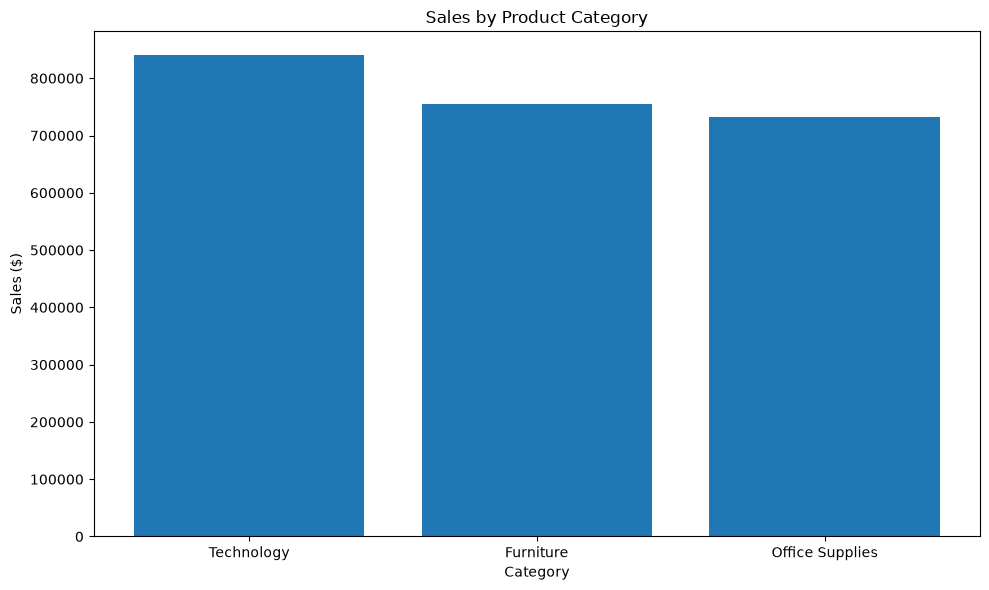

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.bar(
    category_performance.index,
    category_performance["sales"]
)

plt.title("Sales by Product Category")
plt.xlabel("Category")
plt.ylabel("Sales ($)")
plt.xticks(rotation=0)

plt.tight_layout()

plt.savefig(
    "../images/sales_by_category.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [37]:
category_profit = (
    df_clean
    .groupby("category")
    .agg(
        sales=("sales", "sum"),
        profit=("profit", "sum"),
        quantity=("quantity", "sum"),
        orders=("order_id", "nunique")
    )
)

category_profit["profit_margin"] = (
    category_profit["profit"] / category_profit["sales"] * 100
)

category_profit = category_profit.sort_values(
    "profit",
    ascending=False
)

category_profit

,sales,profit,quantity,orders,profit_margin
category,,,,,
Technology,839893.2790,146543.3756,7017,1560,17.447857
Office Supplies,731893.3140,126023.4434,23268,3812,17.218827
Furniture,754747.7613,19729.9956,8369,1819,2.614118


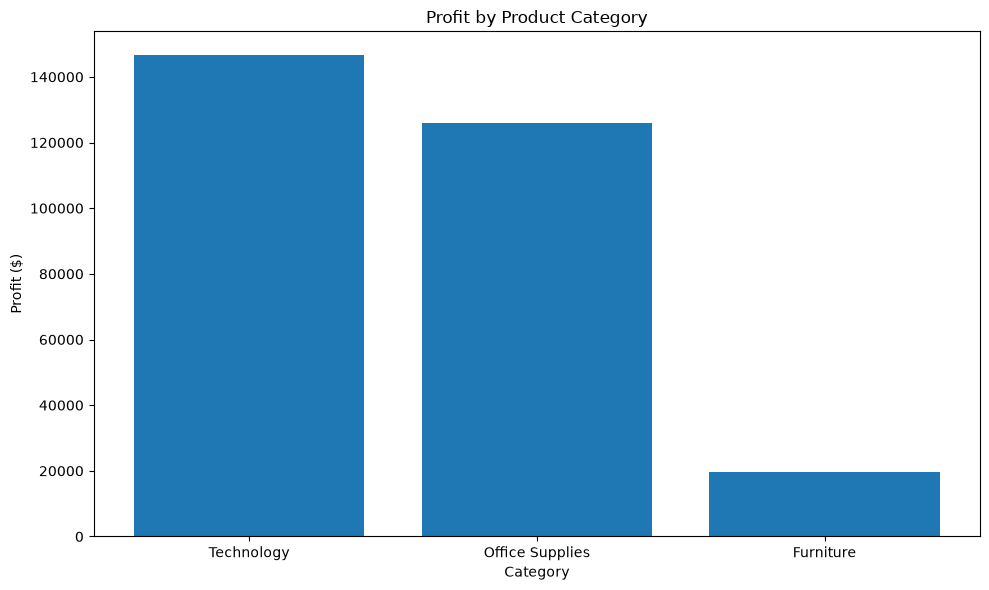

In [38]:
plt.figure(figsize=(10, 6))

plt.bar(
    category_profit.index,
    category_profit["profit"]
)

plt.title("Profit by Product Category")
plt.xlabel("Category")
plt.ylabel("Profit ($)")
plt.xticks(rotation=0)

plt.tight_layout()

plt.savefig(
    "../images/profit_by_category.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [39]:
most_profitable_category = category_profit["profit"].idxmax()
most_profitable_profit = category_profit["profit"].max()

print(f"Most profitable category: {most_profitable_category}")
print(f"Profit: ${most_profitable_profit:,.2f}")

Most profitable category: Technology
Profit: $146,543.38


In [40]:
monthly_performance = (
    df_clean
    .set_index("order_date")
    .resample("ME")
    .agg(
        sales=("sales", "sum"),
        profit=("profit", "sum")
    )
)

monthly_performance

,sales,profit
order_date,,
2023-01-31,14518.0550,2539.3907
2023-02-28,4519.8920,862.3084
2023-03-31,56933.9090,693.4499
2023-04-30,28295.3450,3488.8352
2023-05-31,26319.7670,3196.3918
2023-06-30,34669.4796,4999.7594
2023-07-31,33946.3930,-841.4826
2023-08-31,28918.3385,5765.2250
2023-09-30,82670.4288,8593.6302


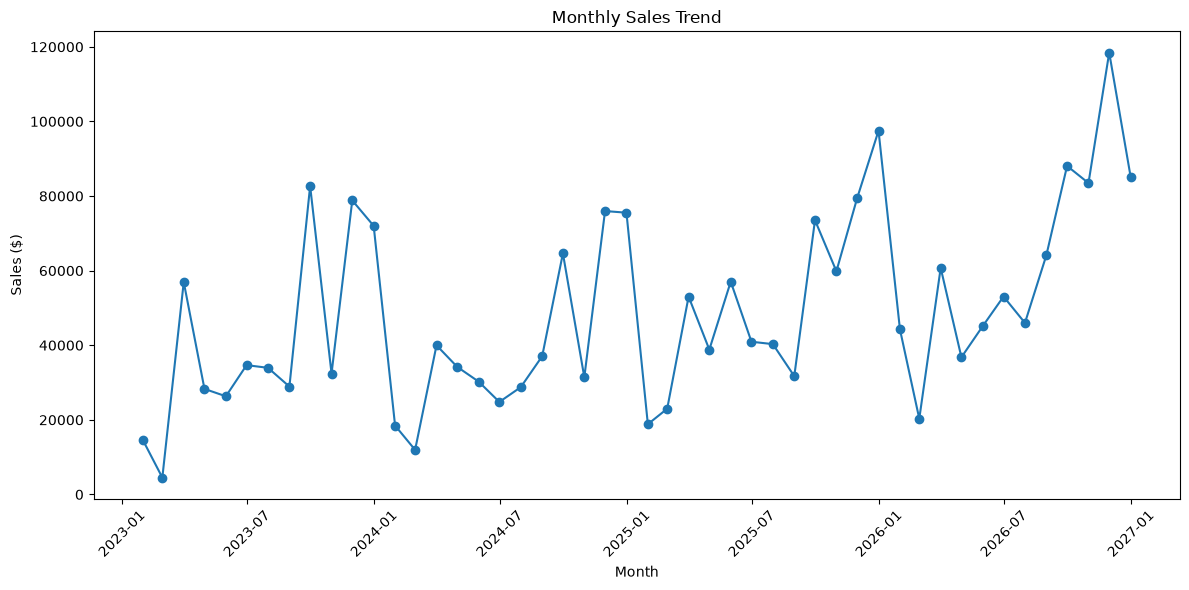

In [41]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_performance.index,
    monthly_performance["sales"],
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales ($)")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "../images/monthly_sales_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

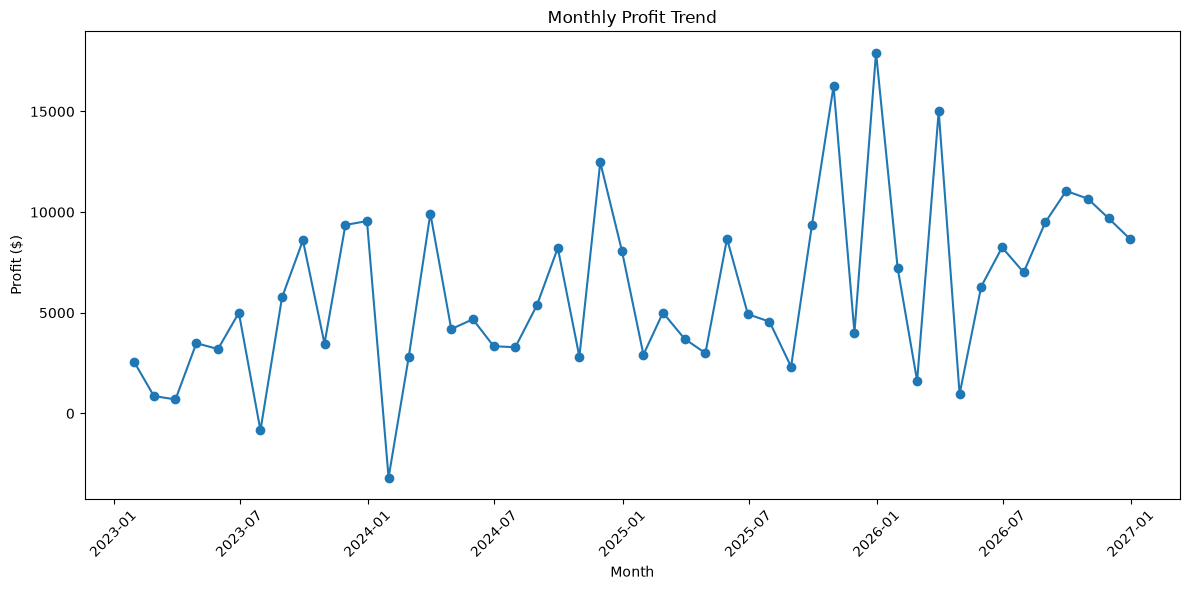

In [42]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_performance.index,
    monthly_performance["profit"],
    marker="o"
)

plt.title("Monthly Profit Trend")
plt.xlabel("Month")
plt.ylabel("Profit ($)")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "../images/monthly_profit_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [43]:
best_sales_month = monthly_performance["sales"].idxmax()
best_sales_value = monthly_performance["sales"].max()

best_profit_month = monthly_performance["profit"].idxmax()
best_profit_value = monthly_performance["profit"].max()

worst_profit_month = monthly_performance["profit"].idxmin()
worst_profit_value = monthly_performance["profit"].min()

print(
    f"Best sales month: "
    f"{best_sales_month.strftime('%B %Y')} "
    f"(${best_sales_value:,.2f})"
)

print(
    f"Best profit month: "
    f"{best_profit_month.strftime('%B %Y')} "
    f"(${best_profit_value:,.2f})"
)

print(
    f"Worst profit month: "
    f"{worst_profit_month.strftime('%B %Y')} "
    f"(${worst_profit_value:,.2f})"
)

Best sales month: November 2026 ($118,454.51)
Best profit month: December 2025 ($17,926.30)
Worst profit month: January 2024 ($-3,189.80)


In [44]:
subcategory_performance = (
    df_clean
    .groupby("sub-category")
    .agg(
        sales=("sales", "sum"),
        profit=("profit", "sum"),
        quantity=("quantity", "sum"),
        orders=("order_id", "nunique")
    )
)

subcategory_performance["profit_margin"] = (
    subcategory_performance["profit"]
    / subcategory_performance["sales"]
    * 100
)

subcategory_performance = subcategory_performance.sort_values(
    "profit",
    ascending=False
)

subcategory_performance

,sales,profit,quantity,orders,profit_margin
sub-category,,,,,
Copiers,150745.2900,56093.9365,242,70,37.211071
Phones,331842.6400,45050.8265,3357,826,13.575961
Accessories,167380.3180,41936.6357,2976,718,25.054700
Paper,79540.5380,34511.5070,5207,1205,43.388576
Binders,207354.8810,31426.1003,6071,1339,15.155708
Chairs,335768.2490,27223.5323,2431,591,8.107834
Storage,224644.5540,21285.1115,3191,787,9.475018
Appliances,108213.1850,18329.4844,1750,459,16.938310
Furnishings,95598.1260,13891.7430,3799,919,14.531397


In [45]:
best_subcategory = subcategory_performance["profit"].idxmax()
best_subcategory_profit = subcategory_performance["profit"].max()

worst_subcategory = subcategory_performance["profit"].idxmin()
worst_subcategory_profit = subcategory_performance["profit"].min()

print(
    f"Most profitable sub-category: "
    f"{best_subcategory} "
    f"(${best_subcategory_profit:,.2f})"
)

print(
    f"Least profitable sub-category: "
    f"{worst_subcategory} "
    f"(${worst_subcategory_profit:,.2f})"
)

Most profitable sub-category: Copiers ($56,093.94)
Least profitable sub-category: Tables ($-17,753.21)


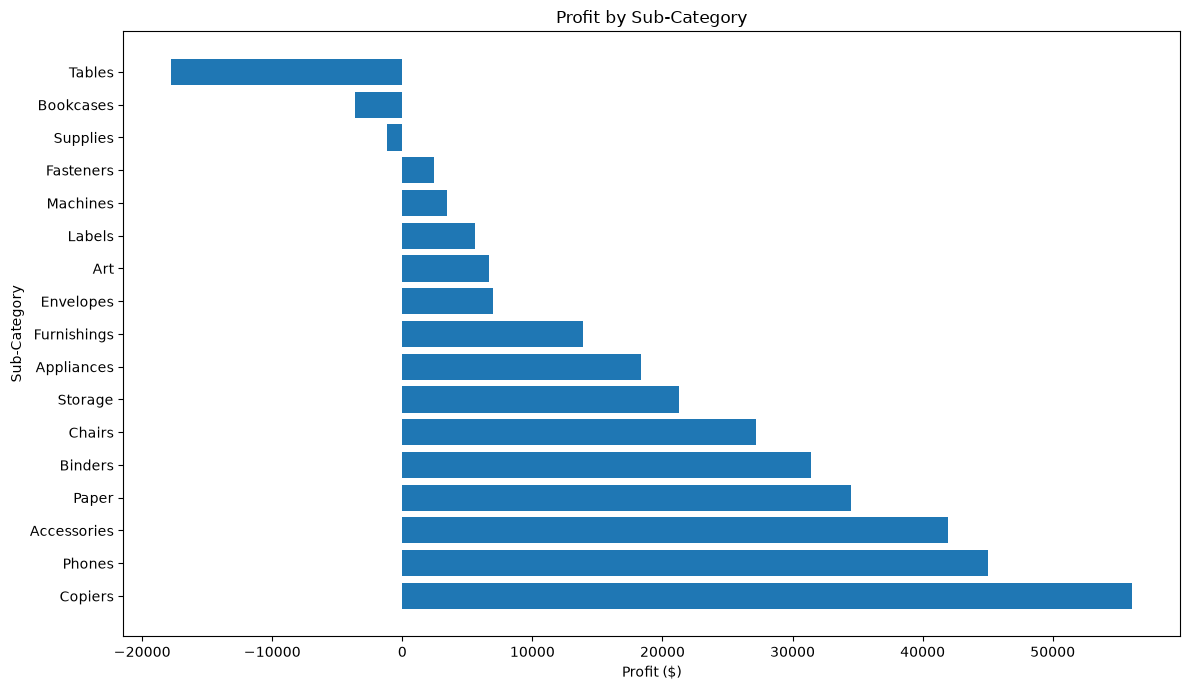

In [46]:
plt.figure(figsize=(12, 7))

plt.barh(
    subcategory_performance.index,
    subcategory_performance["profit"]
)

plt.title("Profit by Sub-Category")
plt.xlabel("Profit ($)")
plt.ylabel("Sub-Category")

plt.tight_layout()

plt.savefig(
    "../images/profit_by_subcategory.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [47]:
table_analysis = (
    df_clean[df_clean["sub-category"] == "Tables"]
    .agg(
        total_sales=("sales", "sum"),
        total_profit=("profit", "sum"),
        average_discount=("discount", "mean"),
        maximum_discount=("discount", "max"),
        total_quantity=("quantity", "sum"),
        unique_orders=("order_id", "nunique")
    )
)

table_analysis

,sales,profit,discount,quantity,order_id
total_sales,208020.182,NaN,NaN,NaN,NaN
total_profit,NaN,-17753.2061,NaN,NaN,NaN
average_discount,NaN,NaN,0.258129,NaN,NaN
maximum_discount,NaN,NaN,0.500000,NaN,NaN
total_quantity,NaN,NaN,NaN,1261.0,NaN
unique_orders,NaN,NaN,NaN,NaN,314.0


In [48]:
overall_average_discount = df_clean["discount"].mean()

table_average_discount = df_clean[
    df_clean["sub-category"] == "Tables"
]["discount"].mean()

print(f"Overall average discount: {overall_average_discount:.2%}")
print(f"Tables average discount: {table_average_discount:.2%}")
print(
    f"Difference: "
    f"{(table_average_discount - overall_average_discount):.2%}"
)

Overall average discount: 15.54%
Tables average discount: 25.81%
Difference: 10.27%


In [49]:
table_discount_analysis = (
    df_clean[df_clean["sub-category"] == "Tables"]
    .groupby("discount")
    .agg(
        sales=("sales", "sum"),
        profit=("profit", "sum"),
        quantity=("quantity", "sum"),
        orders=("order_id", "nunique")
    )
    .sort_index()
)

table_discount_analysis

,sales,profit,quantity,orders
discount,,,,
0.00,71706.230,13334.9247,323,74
0.20,45636.582,-298.3980,284,70
0.30,25902.980,-3493.8376,184,53
0.40,45614.406,-16187.3968,292,72
0.45,5484.974,-2493.1111,45,10
0.50,13675.010,-8615.3873,133,35


In [50]:
table_df = df_clean[df_clean["sub-category"] == "Tables"]

table_summary = pd.Series({
    "Total Sales": table_df["sales"].sum(),
    "Total Profit": table_df["profit"].sum(),
    "Average Discount": table_df["discount"].mean(),
    "Maximum Discount": table_df["discount"].max(),
    "Total Quantity": table_df["quantity"].sum(),
    "Unique Orders": table_df["order_id"].nunique()
})

table_summary

Total Sales         208020.182000
Total Profit        -17753.206100
Average Discount         0.258129
Maximum Discount         0.500000
Total Quantity        1261.000000
Unique Orders          314.000000
dtype: float64

In [51]:
table_discount_analysis["profit_margin"] = (
    table_discount_analysis["profit"]
    / table_discount_analysis["sales"]
    * 100
)

table_discount_analysis

,sales,profit,quantity,orders,profit_margin
discount,,,,,
0.00,71706.230,13334.9247,323,74,18.596605
0.20,45636.582,-298.3980,284,70,-0.653857
0.30,25902.980,-3493.8376,184,53,-13.488169
0.40,45614.406,-16187.3968,292,72,-35.487466
0.45,5484.974,-2493.1111,45,10,-45.453472
0.50,13675.010,-8615.3873,133,35,-63.000958


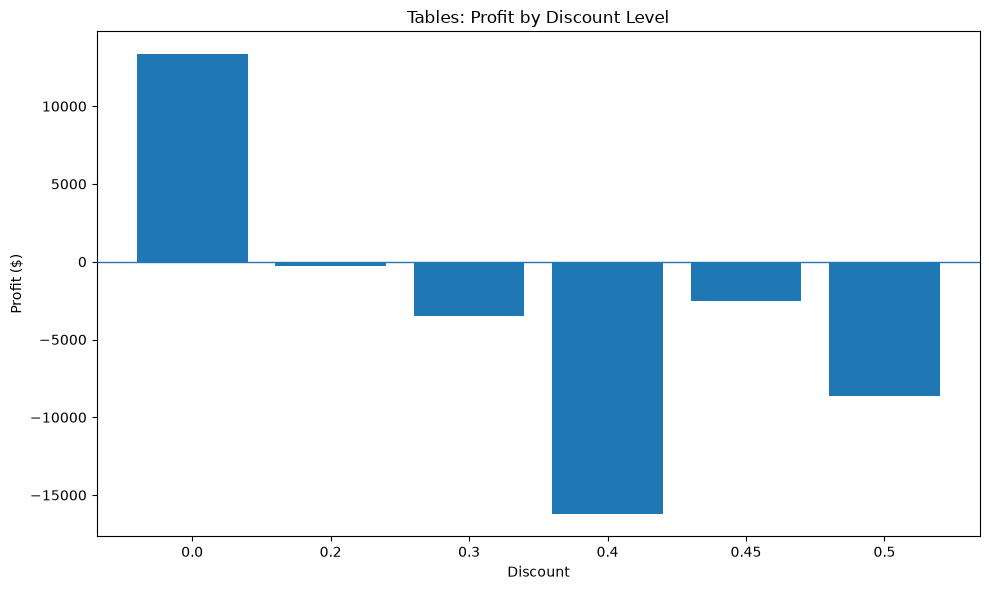

In [52]:
plt.figure(figsize=(10, 6))

plt.bar(
    table_discount_analysis.index.astype(str),
    table_discount_analysis["profit"]
)

plt.axhline(0, linewidth=1)

plt.title("Tables: Profit by Discount Level")
plt.xlabel("Discount")
plt.ylabel("Profit ($)")

plt.tight_layout()

plt.savefig(
    "../images/tables_profit_by_discount.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [53]:
no_discount_profit = table_discount_analysis.loc[0.0, "profit"]

discounted_profit = table_discount_analysis.loc[
    table_discount_analysis.index > 0,
    "profit"
].sum()

print(f"Profit with 0% discount: ${no_discount_profit:,.2f}")
print(f"Profit from discounted sales: ${discounted_profit:,.2f}")
print(
    f"Difference: "
    f"${discounted_profit - no_discount_profit:,.2f}"
)

Profit with 0% discount: $13,334.92
Profit from discounted sales: $-31,088.13
Difference: $-44,423.06


In [54]:
table_product_performance = (
    df_clean[df_clean["sub-category"] == "Tables"]
    .groupby("product_name")
    .agg(
        sales=("sales", "sum"),
        profit=("profit", "sum"),
        quantity=("quantity", "sum"),
        orders=("order_id", "nunique"),
        average_discount=("discount", "mean")
    )
    .sort_values("profit")
)

table_product_performance

,sales,profit,quantity,orders,average_discount
product_name,,,,,
Chromcraft Bull-Nose Wood Oval Conference Tables & Bases,9917.6400,-2876.1156,27,5,0.280000
Bush Advantage Collection Racetrack Conference Table,9544.7250,-1934.3976,33,7,0.350000
Balt Solid Wood Round Tables,6518.7540,-1201.0581,19,4,0.200000
BoxOffice By Design Rectangular and Half-Moon Meeting Room Tables,1706.2500,-1148.4375,15,3,0.483333
"Riverside Furniture Oval Coffee Table, Oval End Table, End Table with Drawer",4446.1750,-1147.4000,25,5,0.300000
Bretford “Just In Time” Height-Adjustable Multi-Task Work Tables,5634.9000,-964.1940,17,4,0.225000
"Bevis Oval Conference Table, Walnut",6942.0680,-856.0144,36,8,0.275000
BPI Conference Tables,2241.8675,-795.9725,26,5,0.370000
Hon 94000 Series Round Tables,7404.5000,-681.2140,30,5,0.160000


In [55]:
worst_table_products = table_product_performance.head(10)

worst_table_products

,sales,profit,quantity,orders,average_discount
product_name,,,,,
Chromcraft Bull-Nose Wood Oval Conference Tables & Bases,9917.6400,-2876.1156,27,5,0.280000
Bush Advantage Collection Racetrack Conference Table,9544.7250,-1934.3976,33,7,0.350000
Balt Solid Wood Round Tables,6518.7540,-1201.0581,19,4,0.200000
BoxOffice By Design Rectangular and Half-Moon Meeting Room Tables,1706.2500,-1148.4375,15,3,0.483333
"Riverside Furniture Oval Coffee Table, Oval End Table, End Table with Drawer",4446.1750,-1147.4000,25,5,0.300000
Bretford “Just In Time” Height-Adjustable Multi-Task Work Tables,5634.9000,-964.1940,17,4,0.225000
"Bevis Oval Conference Table, Walnut",6942.0680,-856.0144,36,8,0.275000
BPI Conference Tables,2241.8675,-795.9725,26,5,0.370000
Hon 94000 Series Round Tables,7404.5000,-681.2140,30,5,0.160000


In [56]:
top_loss_products_profit = worst_table_products["profit"].sum()
total_table_loss = table_product_performance["profit"].sum()

loss_contribution = (
    abs(top_loss_products_profit)
    / abs(total_table_loss)
    * 100
)

print(
    f"Profit from the 10 worst Table products: "
    f"${top_loss_products_profit:,.2f}"
)

print(
    f"Total Table profit: "
    f"${total_table_loss:,.2f}"
)

print(
    f"Share of total Table loss represented by these products: "
    f"{loss_contribution:.2f}%"
)

Profit from the 10 worst Table products: $-12,216.39
Total Table profit: $-17,753.21
Share of total Table loss represented by these products: 68.81%


In [57]:
table_region_performance = (
    df_clean[df_clean["sub-category"] == "Tables"]
    .groupby("region")
    .agg(
        sales=("sales", "sum"),
        profit=("profit", "sum"),
        quantity=("quantity", "sum"),
        orders=("order_id", "nunique"),
        average_discount=("discount", "mean")
    )
    .sort_values("profit")
)

table_region_performance

,sales,profit,quantity,orders,average_discount
region,,,,,
East,39926.147,-11086.1471,286,81,0.358824
South,43916.192,-4623.0579,227,49,0.222549
Central,39154.971,-3559.6504,262,68,0.262500
West,85022.872,1515.6493,486,116,0.198305


In [58]:
table_region_performance["loss_share"] = (
    table_region_performance["profit"].abs()
    / table_region_performance["profit"].abs().sum()
    * 100
)

table_region_performance

,sales,profit,quantity,orders,average_discount,loss_share
region,,,,,,
East,39926.147,-11086.1471,286,81,0.358824,53.338520
South,43916.192,-4623.0579,227,49,0.222549,22.242810
Central,39154.971,-3559.6504,262,68,0.262500,17.126462
West,85022.872,1515.6493,486,116,0.198305,7.292208


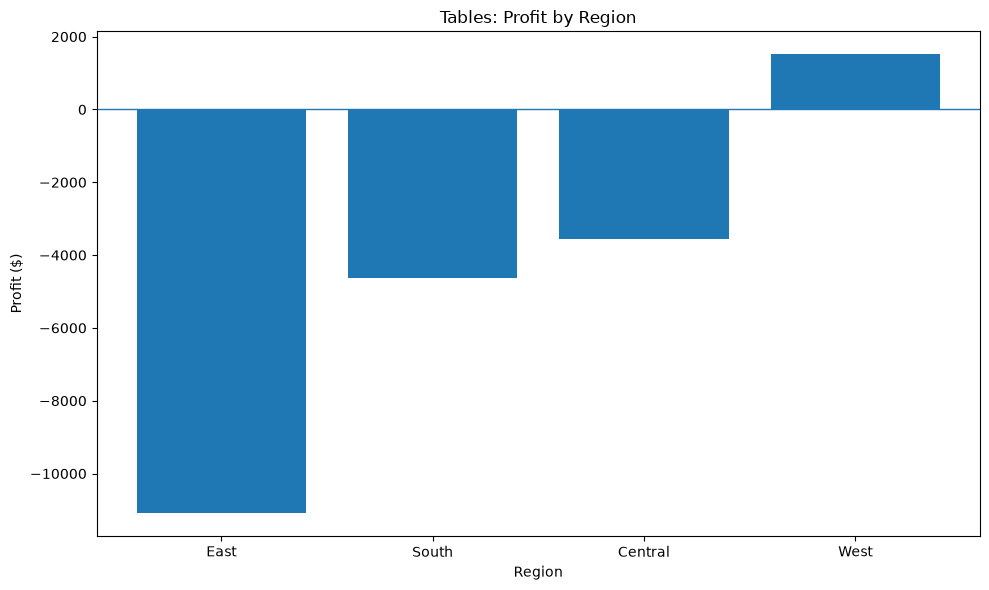

In [59]:
plt.figure(figsize=(10, 6))

plt.bar(
    table_region_performance.index,
    table_region_performance["profit"]
)

plt.axhline(0, linewidth=1)

plt.title("Tables: Profit by Region")
plt.xlabel("Region")
plt.ylabel("Profit ($)")

plt.tight_layout()

plt.savefig(
    "../images/tables_profit_by_region.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [60]:
worst_table_region = table_region_performance["profit"].idxmin()
worst_table_region_profit = table_region_performance["profit"].min()

best_table_region = table_region_performance["profit"].idxmax()
best_table_region_profit = table_region_performance["profit"].max()

print(
    f"Worst region for Tables: "
    f"{worst_table_region} "
    f"(${worst_table_region_profit:,.2f})"
)

print(
    f"Best region for Tables: "
    f"{best_table_region} "
    f"(${best_table_region_profit:,.2f})"
)

Worst region for Tables: East ($-11,086.15)
Best region for Tables: West ($1,515.65)


In [61]:
table_region_discount = (
    df_clean[df_clean["sub-category"] == "Tables"]
    .groupby("region")
    .agg(
        sales=("sales", "sum"),
        profit=("profit", "sum"),
        average_discount=("discount", "mean"),
        maximum_discount=("discount", "max"),
        orders=("order_id", "nunique")
    )
    .sort_values("profit")
)

table_region_discount

,sales,profit,average_discount,maximum_discount,orders
region,,,,,
East,39926.147,-11086.1471,0.358824,0.40,81
South,43916.192,-4623.0579,0.222549,0.45,49
Central,39154.971,-3559.6504,0.262500,0.50,68
West,85022.872,1515.6493,0.198305,0.50,116


In [62]:
table_region_discount["profit_margin"] = (
    table_region_discount["profit"]
    / table_region_discount["sales"]
    * 100
)

table_region_discount

,sales,profit,average_discount,maximum_discount,orders,profit_margin
region,,,,,,
East,39926.147,-11086.1471,0.358824,0.40,81,-27.766634
South,43916.192,-4623.0579,0.222549,0.45,49,-10.527001
Central,39154.971,-3559.6504,0.262500,0.50,68,-9.091184
West,85022.872,1515.6493,0.198305,0.50,116,1.782637


In [63]:
east_table_products = (
    df_clean[
        (df_clean["sub-category"] == "Tables") &
        (df_clean["region"] == "East")
    ]
    .groupby("product_name")
    .agg(
        sales=("sales", "sum"),
        profit=("profit", "sum"),
        quantity=("quantity", "sum"),
        orders=("order_id", "nunique"),
        average_discount=("discount", "mean")
    )
    .sort_values("profit")
)

east_table_products.head(10)

,sales,profit,quantity,orders,average_discount
product_name,,,,,
"Riverside Furniture Oval Coffee Table, Oval End Table, End Table with Drawer",3958.530,-1187.5590,23,3,0.400
"Chromcraft Bull-Nose Wood 48"" x 96"" Rectangular Conference Tables",2369.214,-754.8426,7,4,0.375
Hon 94000 Series Round Tables,1421.664,-734.5264,8,1,0.400
"Bevis Oval Conference Table, Walnut",1879.056,-720.3048,12,3,0.400
Bretford Rectangular Conference Table Tops,3729.772,-637.6903,20,5,0.260
Balt Solid Wood Round Tables,1071.576,-553.6476,4,1,0.400
Chromcraft Round Conference Tables,1969.477,-508.9268,18,5,0.360
Bush Advantage Collection Racetrack Conference Table,1272.630,-466.6310,5,2,0.400
"Office Impressions End Table, 20-1/2""H x 24""W x 20""D",2126.320,-425.2640,10,2,0.300


In [64]:
east_worst_10_profit = east_table_products.head(10)["profit"].sum()
east_total_profit = east_table_products["profit"].sum()

east_loss_contribution = (
    abs(east_worst_10_profit)
    / abs(east_total_profit)
    * 100
)

print(
    f"Profit from East's 10 worst Table products: "
    f"${east_worst_10_profit:,.2f}"
)

print(
    f"Total East Table profit: "
    f"${east_total_profit:,.2f}"
)

print(
    f"Share of East Table loss from these products: "
    f"{east_loss_contribution:.2f}%"
)

Profit from East's 10 worst Table products: $-6,406.46
Total East Table profit: $-11,086.15
Share of East Table loss from these products: 57.79%


In [65]:
east_table_discount = (
    df_clean[
        (df_clean["sub-category"] == "Tables") &
        (df_clean["region"] == "East")
    ]
    .groupby("discount")
    .agg(
        sales=("sales", "sum"),
        profit=("profit", "sum"),
        quantity=("quantity", "sum"),
        orders=("order_id", "nunique")
    )
    .sort_index()
)

east_table_discount["profit_margin"] = (
    east_table_discount["profit"]
    / east_table_discount["sales"]
    * 100
)

east_table_discount

,sales,profit,quantity,orders,profit_margin
discount,,,,,
0.0,65.510,30.7430,11,3,46.928713
0.3,10142.319,-1277.1610,66,22,-12.592396
0.4,29718.318,-9839.7291,209,56,-33.109980


In [66]:
worst_east_discount = east_table_discount["profit"].idxmin()
worst_east_discount_profit = east_table_discount["profit"].min()

best_east_discount = east_table_discount["profit"].idxmax()
best_east_discount_profit = east_table_discount["profit"].max()

print(
    f"Worst East discount level: "
    f"{worst_east_discount:.0%}"
)

print(
    f"Profit at worst discount level: "
    f"${worst_east_discount_profit:,.2f}"
)

print(
    f"Best East discount level: "
    f"{best_east_discount:.0%}"
)

print(
    f"Profit at best discount level: "
    f"${best_east_discount_profit:,.2f}"
)

Worst East discount level: 40%
Profit at worst discount level: $-9,839.73
Best East discount level: 0%
Profit at best discount level: $30.74


In [67]:
worst_table_product = table_product_performance["profit"].idxmin()
worst_table_product_profit = table_product_performance["profit"].min()

print(f"Worst Table product: {worst_table_product}")
print(f"Profit: ${worst_table_product_profit:,.2f}")

Worst Table product: Chromcraft Bull-Nose Wood Oval Conference Tables & Bases
Profit: $-2,876.12


In [68]:
worst_product_details = (
    df_clean[
        df_clean["product_name"] == worst_table_product
    ]
    .agg(
        sales=("sales", "sum"),
        profit=("profit", "sum"),
        quantity=("quantity", "sum"),
        orders=("order_id", "nunique"),
        average_discount=("discount", "mean"),
        maximum_discount=("discount", "max")
    )
)

worst_product_details

,sales,profit,quantity,order_id,discount
sales,9917.64,NaN,NaN,NaN,NaN
profit,NaN,-2876.1156,NaN,NaN,NaN
quantity,NaN,NaN,27.0,NaN,NaN
orders,NaN,NaN,NaN,5.0,NaN
average_discount,NaN,NaN,NaN,NaN,0.28
maximum_discount,NaN,NaN,NaN,NaN,0.40


In [69]:
worst_product_df = df_clean[
    df_clean["product_name"] == worst_table_product
]

worst_product_details = pd.Series({
    "Sales": worst_product_df["sales"].sum(),
    "Profit": worst_product_df["profit"].sum(),
    "Quantity": worst_product_df["quantity"].sum(),
    "Unique Orders": worst_product_df["order_id"].nunique(),
    "Average Discount": worst_product_df["discount"].mean(),
    "Maximum Discount": worst_product_df["discount"].max()
})

worst_product_details

Sales               9917.6400
Profit             -2876.1156
Quantity              27.0000
Unique Orders          5.0000
Average Discount       0.2800
Maximum Discount       0.4000
dtype: float64

In [70]:
worst_product_discount = (
    worst_product_df
    .groupby("discount")
    .agg(
        sales=("sales", "sum"),
        profit=("profit", "sum"),
        quantity=("quantity", "sum"),
        orders=("order_id", "nunique")
    )
    .sort_index()
)

worst_product_discount["profit_margin"] = (
    worst_product_discount["profit"]
    / worst_product_discount["sales"]
    * 100
)

worst_product_discount

,sales,profit,quantity,orders,profit_margin
discount,,,,,
0.0,1652.940,231.4116,3,1,14.000000
0.2,1322.352,-99.1764,3,1,-7.500000
0.4,6942.348,-3008.3508,21,3,-43.333333


In [71]:
profitable_discount_levels = worst_product_discount[
    worst_product_discount["profit"] > 0
]

loss_making_discount_levels = worst_product_discount[
    worst_product_discount["profit"] < 0
]

print("Profitable discount levels:")
print(profitable_discount_levels)

print("\nLoss-making discount levels:")
print(loss_making_discount_levels)

Profitable discount levels:
            sales    profit  quantity  orders  profit_margin
discount                                                    
0.0       1652.94  231.4116         3       1           14.0

Loss-making discount levels:
             sales     profit  quantity  orders  profit_margin
discount                                                      
0.2       1322.352   -99.1764         3       1      -7.500000
0.4       6942.348 -3008.3508        21       3     -43.333333


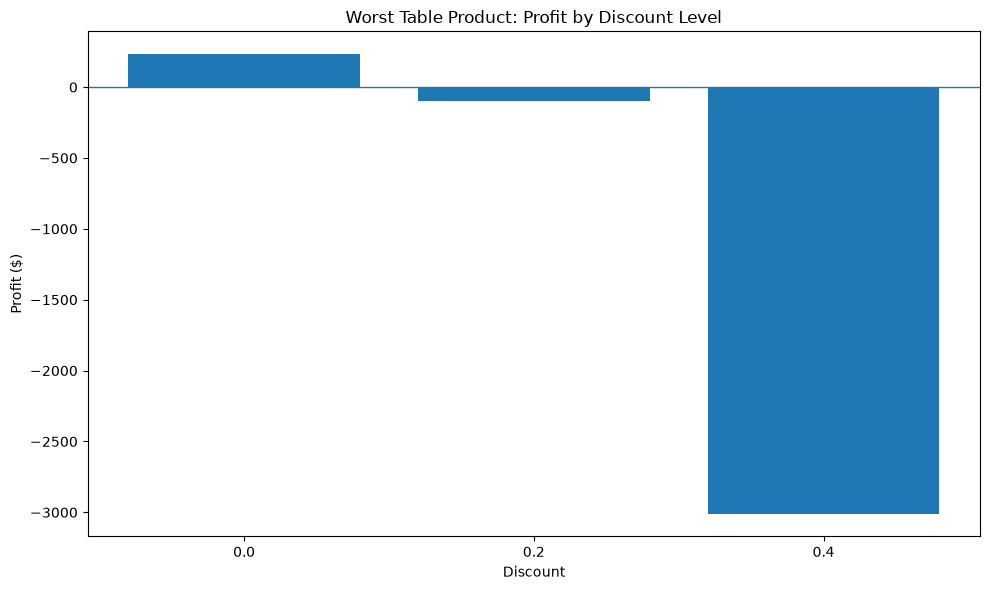

In [72]:
plt.figure(figsize=(10, 6))

plt.bar(
    worst_product_discount.index.astype(str),
    worst_product_discount["profit"]
)

plt.axhline(0, linewidth=1)

plt.title("Worst Table Product: Profit by Discount Level")
plt.xlabel("Discount")
plt.ylabel("Profit ($)")

plt.tight_layout()

plt.savefig(
    "../images/worst_table_product_profit_by_discount.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [73]:
business_findings = pd.DataFrame({
    "Finding": [
        "Technology is the most profitable category",
        "Tables are the least profitable sub-category",
        "Tables have higher average discount than overall business",
        "Top 10 loss-making Table products account for most Table losses",
        "East is the worst region for Tables",
        "East has the highest average Table discount",
        "Top 10 East Table products account for most East Table losses"
    ],
    "Result": [
        "Technology",
        "Tables",
        "25.81% vs 15.54%",
        "68.81%",
        "East (-$11,086.15)",
        "35.88%",
        "57.70%"
    ]
})

business_findings

,Finding,Result
0,Technology is the most profitable category,Technology
1,Tables are the least profitable sub-category,Tables
2,Tables have higher average discount than overa...,25.81% vs 15.54%
3,Top 10 loss-making Table products account for ...,68.81%
4,East is the worst region for Tables,"East (-$11,086.15)"
5,East has the highest average Table discount,35.88%
6,Top 10 East Table products account for most Ea...,57.70%


In [74]:
final_kpi = pd.DataFrame({
    "Metric": [
        "Total Sales",
        "Total Profit",
        "Profit Margin",
        "Total Quantity Sold",
        "Unique Orders",
        "Unique Customers",
        "Unique Products",
        "Average Sales per Order"
    ],
    "Value": [
        total_sales,
        total_profit,
        profit_margin,
        total_quantity,
        unique_orders,
        unique_customers,
        unique_products,
        average_order_value
    ]
})

final_kpi

,Metric,Value
0,Total Sales,2.326534e+06
1,Total Profit,2.922968e+05
2,Profit Margin,1.256361e+01
3,Total Quantity Sold,3.865400e+04
4,Unique Orders,5.111000e+03
5,Unique Customers,8.040000e+02
6,Unique Products,1.862000e+03
7,Average Sales per Order,4.552014e+02


In [75]:
final_category = (
    df_clean
    .groupby("category")
    .agg(
        sales=("sales", "sum"),
        profit=("profit", "sum"),
        quantity=("quantity", "sum"),
        orders=("order_id", "nunique")
    )
)

final_category["profit_margin"] = (
    final_category["profit"]
    / final_category["sales"]
    * 100
)

final_category = final_category.sort_values(
    "profit",
    ascending=False
)

final_category

,sales,profit,quantity,orders,profit_margin
category,,,,,
Technology,839893.2790,146543.3756,7017,1560,17.447857
Office Supplies,731893.3140,126023.4434,23268,3812,17.218827
Furniture,754747.7613,19729.9956,8369,1819,2.614118


In [76]:
final_subcategory = (
    df_clean
    .groupby("sub-category")
    .agg(
        sales=("sales", "sum"),
        profit=("profit", "sum"),
        quantity=("quantity", "sum"),
        orders=("order_id", "nunique")
    )
)

final_subcategory["profit_margin"] = (
    final_subcategory["profit"]
    / final_subcategory["sales"]
    * 100
)

final_subcategory = final_subcategory.sort_values(
    "profit"
)

final_subcategory

,sales,profit,quantity,orders,profit_margin
sub-category,,,,,
Tables,208020.1820,-17753.2061,1261,314,-8.534367
Bookcases,115361.2043,-3632.0736,878,228,-3.148436
Supplies,46725.4980,-1171.3945,653,189,-2.506971
Fasteners,8532.2400,2428.6358,980,226,28.464223
Machines,189925.0310,3461.9769,442,114,1.822812
Labels,12695.0420,5572.7780,1410,348,43.897279
Art,27659.0140,6653.1962,3092,756,24.054351
Envelopes,16528.3620,6988.0247,914,251,42.278991
Furnishings,95598.1260,13891.7430,3799,919,14.531397


In [77]:
df_clean.to_csv(
    "../data/superstore_cleaned.csv",
    index=False
)

print("Cleaned dataset exported successfully.")
print(f"Rows: {len(df_clean):,}")
print(f"Columns: {len(df_clean.columns)}")

Cleaned dataset exported successfully.
Rows: 10,194
Columns: 21


In [78]:
final_kpi.to_csv(
    "../data/final_kpi_summary.csv",
    index=False
)

print("KPI summary exported successfully.")

KPI summary exported successfully.


In [79]:
final_category.to_csv(
    "../data/category_performance.csv"
)

final_subcategory.to_csv(
    "../data/subcategory_performance.csv"
)

business_findings.to_csv(
    "../data/business_findings.csv",
    index=False
)

print("Final analysis tables exported successfully.")

Final analysis tables exported successfully.


In [80]:
import os

files_to_check = [
    "../data/superstore_cleaned.csv",
    "../data/final_kpi_summary.csv",
    "../data/category_performance.csv",
    "../data/subcategory_performance.csv",
    "../data/business_findings.csv"
]

for file_path in files_to_check:
    print(
        f"{'✓' if os.path.exists(file_path) else '✗'} "
        f"{file_path}"
    )

✓ ../data/superstore_cleaned.csv
✓ ../data/final_kpi_summary.csv
✓ ../data/category_performance.csv
✓ ../data/subcategory_performance.csv
✓ ../data/business_findings.csv


# 3. Key Business Findings

## Overall Performance

The dataset contains 10,194 transaction records representing 5,111 unique orders, 804 customers, and 1,862 products.

Total sales were approximately **USD 2.33 million**, with approximately $292,297 in total profit and a profit margin of approximately 12.56%.

## Category Performance

Technology generated the highest total profit among the three product categories.

Furniture generated substantially lower profit than Technology and Office Supplies.

## Sub-Category Performance

Copiers were the most profitable sub-category, generating approximately $55,694 in profit with a profit margin of approximately 37.21%.

Tables were the least profitable sub-category, generating a loss of approximately $17,753 and a negative profit margin of approximately 8.53%.

## Table Profitability Investigation

Tables had an average discount of approximately 25.81%, compared with an overall dataset average of approximately 15.54%.

Table sales with no discount generated approximately **USD 13,335 in profit**, while discounted Table sales collectively generated a loss of approximately **USD 31,088**.

This indicates a strong association between discounting and poor profitability for Tables. The analysis does not establish that discounting alone caused the losses.

## Product Concentration

The 10 worst-performing Table products accounted for approximately 68.81% of the total loss within the Tables sub-category.

This indicates that the losses are concentrated among a relatively small number of products.

## Regional Performance

The East region was the worst-performing region for Tables, generating a loss of approximately **USD 11,086**.

The East also had the highest average Table discount at approximately 35.88%.

The West was the only region that generated a positive profit from Tables.

## East Region Product Concentration

The 10 worst-performing Table products in the East accounted for approximately 57.70% of the East region's total Table loss.

# 4. Business Recommendations

1. Review discount policies for Table products, particularly high-discount transactions.
2. Investigate the highest-loss Table products individually before continuing aggressive discounting.
3. Review Table pricing and discount strategy in the East region.
4. Consider reducing or restructuring discounts that consistently produce negative margins.
5. Investigate whether the highest-loss products should be repriced, promoted differently, replaced, or discontinued.
6. Continue monitoring Technology products because the category currently generates the strongest profitability.
7. Use product-level and regional profitability rather than sales volume alone when making pricing decisions.

# 5. Deliverables

The project produces:

- Cleaned dataset
- KPI summary
- Category performance analysis
- Sub-category performance analysis
- Business findings
- Business-oriented visualizations